In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [8]:
# Load progress.csv for different env runs
ENV_MAP_NAMES = ['lbf-12x12-6p-20f-mp5','lbf-15x15-8p-40f-mp5'] 
RESULTS_PATH = '../exp_results/'
CKPT_PROGRESS_PATH= {k:{} for k in ENV_MAP_NAMES}

for run_name in os.listdir(RESULTS_PATH):
    for map_name in ENV_MAP_NAMES:
        if map_name in run_name:
            for log_dir in os.listdir(os.path.join(RESULTS_PATH, run_name)):
                if os.path.isdir(os.path.join(RESULTS_PATH, run_name, log_dir)):
                    if run_name not in CKPT_PROGRESS_PATH[map_name]:
                        CKPT_PROGRESS_PATH[map_name][run_name] = \
                            [os.path.join(RESULTS_PATH, run_name, log_dir, 'progress.csv')]
                    else:
                        CKPT_PROGRESS_PATH[map_name][run_name]\
                            .append(os.path.join(RESULTS_PATH, run_name, log_dir, 'progress.csv'))

In [13]:
CKPT_PROGRESS_CSV = {k:{} for k in ENV_MAP_NAMES}
for map_name, progress_dict in CKPT_PROGRESS_PATH.items():   
    for run_name, progress_csvs in progress_dict.items():   
        print("Loading progress.csv for run: ", run_name)
        print("Progress csvs: ", progress_csvs)
        CKPT_PROGRESS_CSV[map_name][run_name] = []
        for f in progress_csvs:
            try:
                f = pd.read_csv(f)
                CKPT_PROGRESS_CSV[map_name][run_name].append(f)
            except:
                print("Warning: Cant load progress.csv: ", f)
                continue
                
        # CKPT_PROGRESS_CSV[map_name][run_name] = list(filter(lambda x: len(x) > 0, CKPT_PROGRESS_CSV[map_name][run_name]))
        # Merge all progress.csv files into one
        print("Merging progress.csv for run: ", len(CKPT_PROGRESS_CSV[map_name][run_name]))
        CKPT_PROGRESS_CSV[map_name][run_name] = pd.concat(CKPT_PROGRESS_CSV[map_name][run_name])
        CKPT_PROGRESS_CSV[map_name][run_name] = CKPT_PROGRESS_CSV[map_name][run_name].sort_values(by='timesteps_total')
        CKPT_PROGRESS_CSV[map_name][run_name] = CKPT_PROGRESS_CSV[map_name][run_name][['timesteps_total', 'episode_reward_mean', 'episode_len_mean']]
        
    # for run in os.listdir(run_folder):
    #     run_ckpt_folder = os.path.join(run_folder, run)
    #     if not os.path.isdir(run_ckpt_folder):
    #         continue
    #     print("Peeking into run: ", run_ckpt_folder)
    #     ckpts = filter(lambda f: os.path.isdir(os.path.join(run_ckpt_folder, f)),
    #                             os.listdir(run_ckpt_folder))
        
    #     ckpts = list(filter(lambda f: f.startswith('checkpoint_'), ckpts))
    #     if len(ckpts) == 0:
    #         continue
    #     ckpts_num = list(map(lambda f: (int(f.split('_')[1]),f), ckpts))

    #     cp_num = max(ckpts_num, key=lambda x: x[0])
    #     print("Checkpoint number: ", cp_num)
    #     if recent_checkpoint is None or cp_num[0] > recent_checkpoint[0]:
    #         recent_checkpoint = cp_num
    #         params_path = os.path.join(run_ckpt_folder, 'params.json')
    #         model_path = os.path.join(run_ckpt_folder, 
    #                                     recent_checkpoint[1],
    #                                     'checkpoint-{}'.format(cp_num[0]))


Loading progress.csv for run:  mappo_mlp_lbf-12x12-6p-20f-mp5v1_noroles
Progress csvs:  ['../exp_results/mappo_mlp_lbf-12x12-6p-20f-mp5v1_noroles/MAPPOTrainer_lbf_lbf-12x12-6p-20f-mp5v1_noroles_21e8d_00000_0_2024-03-26_13-09-52/progress.csv']
Merging progress.csv for run:  1
Loading progress.csv for run:  mappo_mlp_lbf-12x12-6p-20f-mp5v1_roles
Progress csvs:  ['../exp_results/mappo_mlp_lbf-12x12-6p-20f-mp5v1_roles/MAPPOTrainer_lbf_lbf-12x12-6p-20f-mp5v1_roles_fddb9_00000_0_2024-03-26_04-11-59/progress.csv']
Merging progress.csv for run:  1
Loading progress.csv for run:  mappo_mlp_lbf-15x15-8p-40f-mp5v1_roles
Progress csvs:  ['../exp_results/mappo_mlp_lbf-15x15-8p-40f-mp5v1_roles/MAPPOTrainer_lbf_lbf-15x15-8p-40f-mp5v1_roles_2336a_00000_0_2024-03-28_14-19-07/progress.csv', '../exp_results/mappo_mlp_lbf-15x15-8p-40f-mp5v1_roles/MAPPOTrainer_lbf_lbf-15x15-8p-40f-mp5v1_roles_f8c20_00000_0_2024-03-28_04-59-35/progress.csv', '../exp_results/mappo_mlp_lbf-15x15-8p-40f-mp5v1_roles/MAPPOTrainer

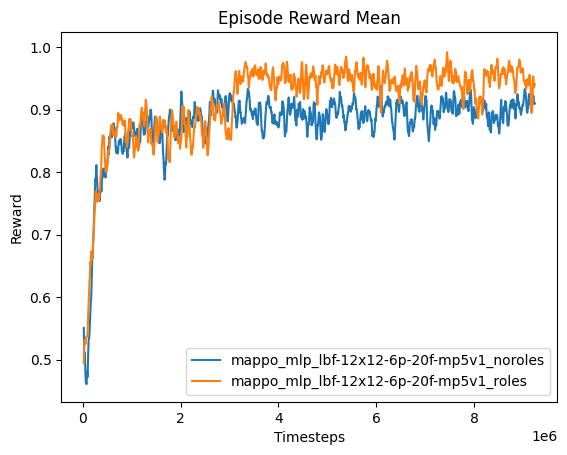

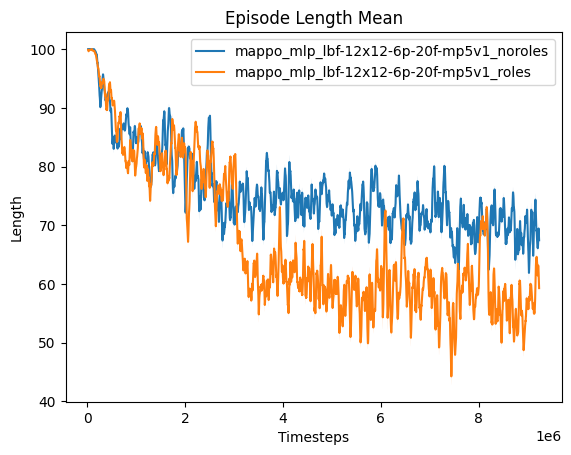

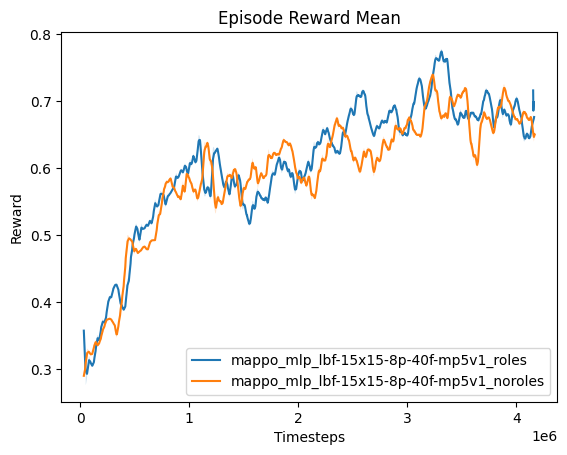

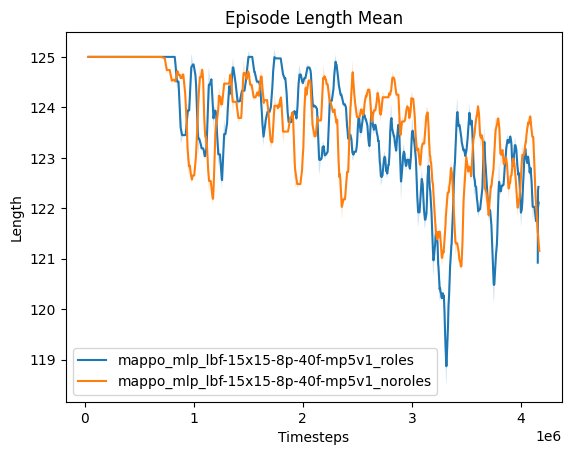

In [14]:
#Plotting all the runs with averaging and std mean

for map_name, progress_dict in CKPT_PROGRESS_CSV.items():
    for run_name, progress_df in progress_dict.items():
        progress_df['episode_reward_mean'] = progress_df['episode_reward_mean'].rolling(window=10).mean()
        progress_df['episode_len_mean'] = progress_df['episode_len_mean'].rolling(window=10).mean()
        progress_df['episode_reward_std'] = progress_df['episode_reward_mean'].rolling(window=10).std()
        progress_df['episode_len_std'] = progress_df['episode_len_mean'].rolling(window=10).std()
        plt.plot(progress_df['timesteps_total'], progress_df['episode_reward_mean'], label=run_name)
        plt.fill_between(progress_df['timesteps_total'], 
                         progress_df['episode_reward_mean'] - progress_df['episode_reward_std'],
                         progress_df['episode_reward_mean'] + progress_df['episode_reward_std'],
                         alpha=0.2)
    plt.title('Episode Reward Mean')
    plt.xlabel('Timesteps')
    plt.ylabel('Reward')
    plt.legend()
    plt.show()
    plt.close()

    for run_name, progress_df in progress_dict.items():
        plt.plot(progress_df['timesteps_total'], progress_df['episode_len_mean'], label=run_name)
        plt.fill_between(progress_df['timesteps_total'], 
                         progress_df['episode_len_mean'] - progress_df['episode_len_std'],
                         progress_df['episode_len_mean'] + progress_df['episode_len_std'],
                         alpha=0.2)
    plt.title('Episode Length Mean')
    plt.xlabel('Timesteps')
    plt.ylabel('Length')
    plt.legend()
    plt.show()
    plt.close()